In [23]:
from IPython.display import HTML, display

display(HTML("""
<style>
/* Classic Notebook */
div.output_scroll {
  height: auto !important;
  max-height: none !important;
  overflow-y: visible !important;
}

/* JupyterLab */
.jp-OutputArea-output {
  max-height: none !important;
}
</style>
"""))


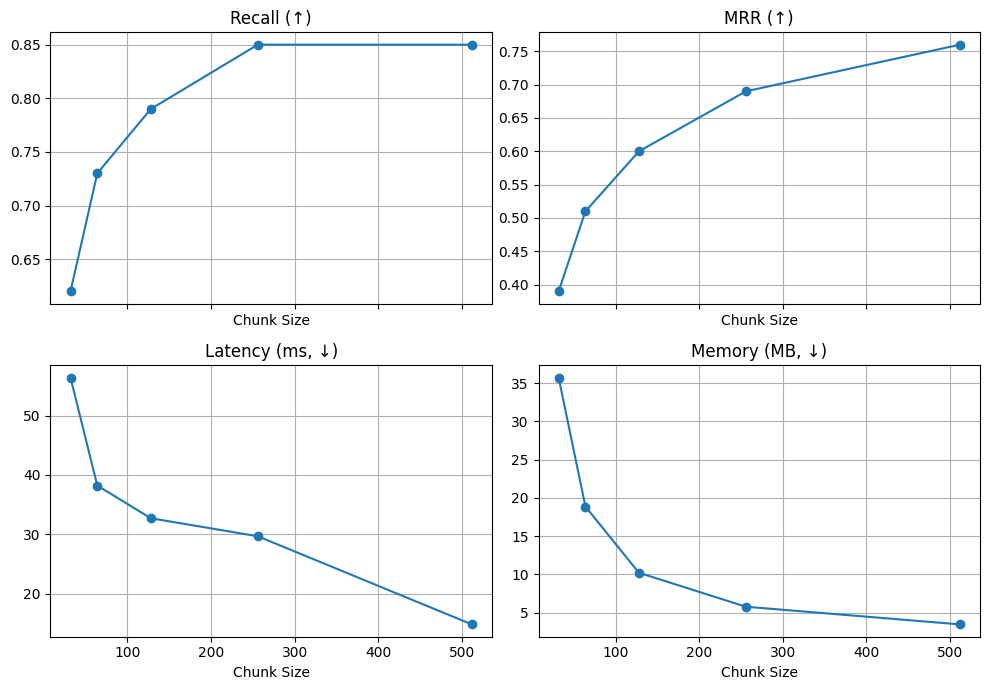

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
df = pd.DataFrame({
    "chunk_size": [32, 64, 128, 256, 512],
    "recall":     [0.62, 0.73, 0.79, 0.85, 0.85],
    "mrr":        [0.39, 0.51, 0.60, 0.69, 0.76],
    "latency_ms": [56.40, 38.22, 32.71, 29.67, 14.81],
    "memory_mb":  [35.70, 18.86, 10.20, 5.76,  3.45],
})

metrics = [("recall", "Recall (↑)"),
           ("mrr", "MRR (↑)"),
           ("latency_ms", "Latency (ms, ↓)"),
           ("memory_mb", "Memory (MB, ↓)")]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
axes = axes.ravel()

for ax, (col, title) in zip(axes, metrics):
    ax.plot(df["chunk_size"], df[col], marker="o")
    ax.set_title(title)
    ax.set_xlabel("Chunk Size")
    ax.grid(True)

plt.tight_layout()
plt.show()


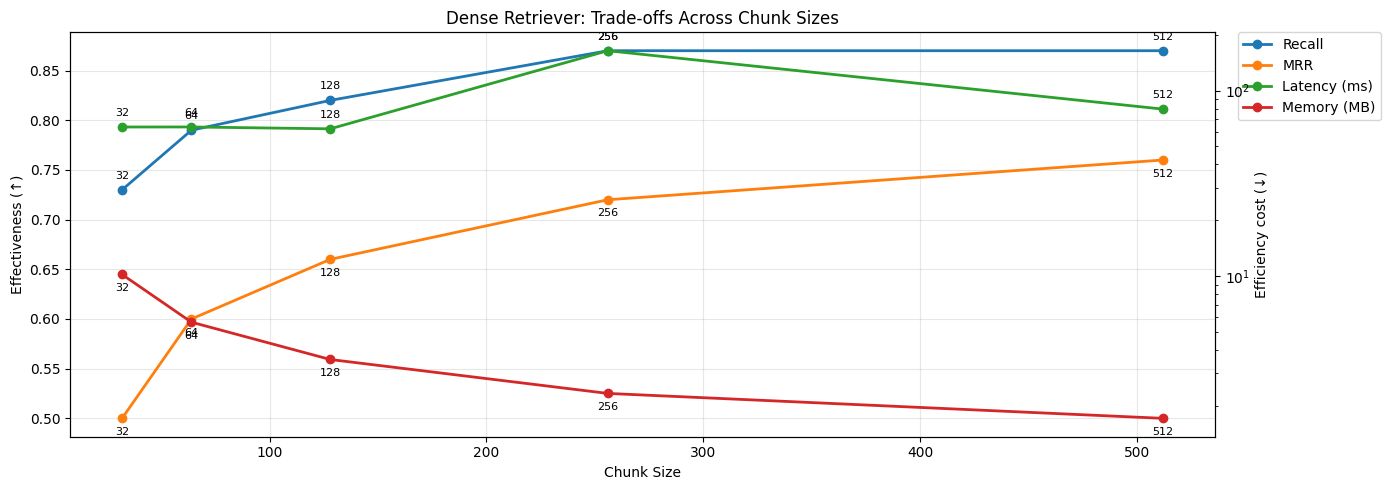

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Updated results
df = pd.DataFrame({
    "chunk_size": [32, 64, 128, 256, 512],
    "recall":     [0.73, 0.79, 0.82, 0.87, 0.87],
    "mrr":        [0.50, 0.60, 0.66, 0.72, 0.76],
    "latency_ms": [63.60, 63.63, 62.19, 163.95, 79.42],
    "memory_mb":  [10.20, 5.64,  3.55,  2.33,  1.71],
})

x = df["chunk_size"]

fig, ax1 = plt.subplots(figsize=(14, 5))  # wider

# Left axis (effectiveness)
l1, = ax1.plot(x, df["recall"], marker="o", color="tab:blue",   linewidth=2, label="Recall")
l2, = ax1.plot(x, df["mrr"],    marker="o", color="tab:orange", linewidth=2, label="MRR")
ax1.set_xlabel("Chunk Size")
ax1.set_ylabel("Effectiveness (↑)")
ax1.grid(True, alpha=0.3)

# Add some horizontal padding so labels don’t crash into the edges
ax1.margins(x=0.12)

# Right axis (efficiency)
ax2 = ax1.twinx()
l3, = ax2.plot(x, df["latency_ms"], marker="o", color="tab:green", linewidth=2, label="Latency (ms)")
l4, = ax2.plot(x, df["memory_mb"],  marker="o", color="tab:red",   linewidth=2, label="Memory (MB)")
ax2.set_ylabel("Efficiency cost (↓)")

# Optional but helpful here (because latency spikes at 256)
ax2.set_yscale("log")

# Annotate chunk size at each point (slightly different offsets to reduce overlap)
def annotate(ax, xs, ys, dy):
    for xi, yi in zip(xs, ys):
        ax.annotate(f"{int(xi)}", (xi, yi),
                    textcoords="offset points", xytext=(0, dy),
                    ha="center", fontsize=8)

annotate(ax1, x, df["recall"],  8)
annotate(ax1, x, df["mrr"],   -12)
annotate(ax2, x, df["latency_ms"], 8)
annotate(ax2, x, df["memory_mb"], -12)

# Legend outside
ax1.legend([l1, l2, l3, l4],
           ["Recall", "MRR", "Latency (ms)", "Memory (MB)"],
           loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

plt.title("Dense Retriever: Trade-offs Across Chunk Sizes")
plt.tight_layout()
plt.show()


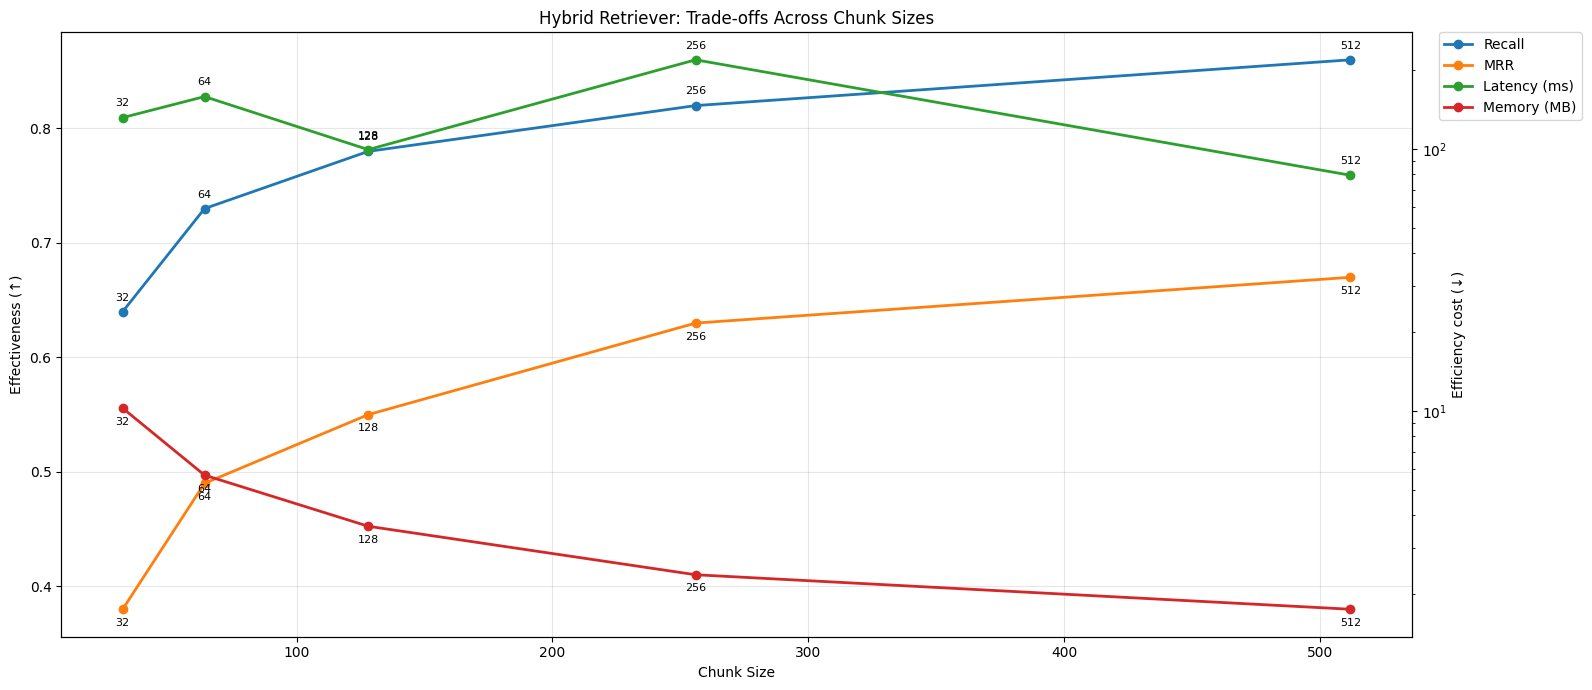

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Hybrid Retriever results
df_hybrid = pd.DataFrame({
    "chunk_size": [32, 64, 128, 256, 512],
    "recall":     [0.64, 0.73, 0.78, 0.82, 0.86],
    "mrr":        [0.38, 0.49, 0.55, 0.63, 0.67],
    "latency_ms": [131.85, 158.61, 99.51, 219.15, 79.42],
    "memory_mb":  [10.25, 5.69, 3.63, 2.37, 1.75],
})

x = df_hybrid["chunk_size"]

fig, ax1 = plt.subplots(figsize=(16, 7))  # wider

# Left axis: effectiveness
l1, = ax1.plot(x, df_hybrid["recall"], marker="o", color="tab:blue",   linewidth=2, label="Recall")
l2, = ax1.plot(x, df_hybrid["mrr"],    marker="o", color="tab:orange", linewidth=2, label="MRR")
ax1.set_xlabel("Chunk Size")
ax1.set_ylabel("Effectiveness (↑)")
ax1.grid(True, alpha=0.3)
ax1.margins(x=0.12)

# Right axis: efficiency
ax2 = ax1.twinx()
l3, = ax2.plot(x, df_hybrid["latency_ms"], marker="o", color="tab:green", linewidth=2, label="Latency (ms)")
l4, = ax2.plot(x, df_hybrid["memory_mb"],  marker="o", color="tab:red",   linewidth=2, label="Memory (MB)")
ax2.set_ylabel("Efficiency cost (↓)")

# Optional: helps when latency varies a lot
ax2.set_yscale("log")

# Annotate chunk size at each point
def annotate(ax, xs, ys, dy):
    for xi, yi in zip(xs, ys):
        ax.annotate(f"{int(xi)}", (xi, yi),
                    textcoords="offset points", xytext=(0, dy),
                    ha="center", fontsize=8)

annotate(ax1, x, df_hybrid["recall"],  8)
annotate(ax1, x, df_hybrid["mrr"],   -12)
annotate(ax2, x, df_hybrid["latency_ms"], 8)
annotate(ax2, x, df_hybrid["memory_mb"], -12)

# Legend outside
ax1.legend([l1, l2, l3, l4],
           ["Recall", "MRR", "Latency (ms)", "Memory (MB)"],
           loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

plt.title("Hybrid Retriever: Trade-offs Across Chunk Sizes")
plt.tight_layout()
plt.show()


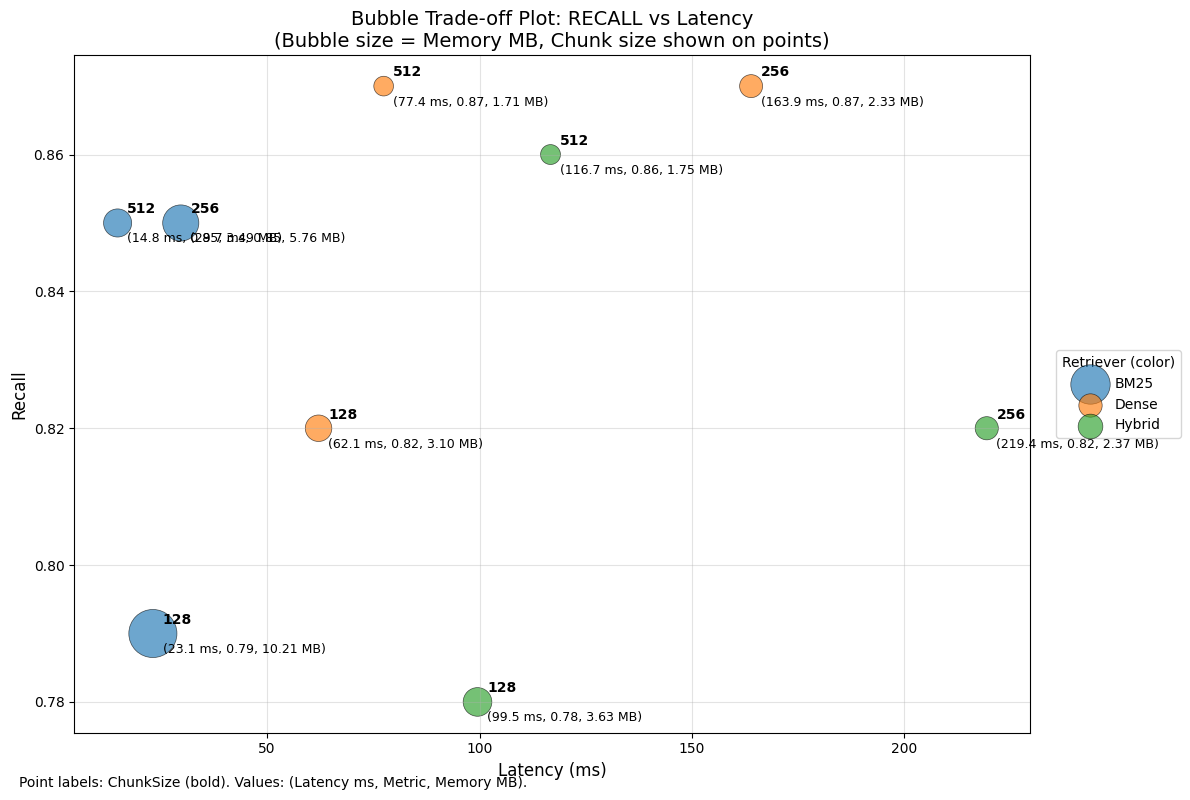

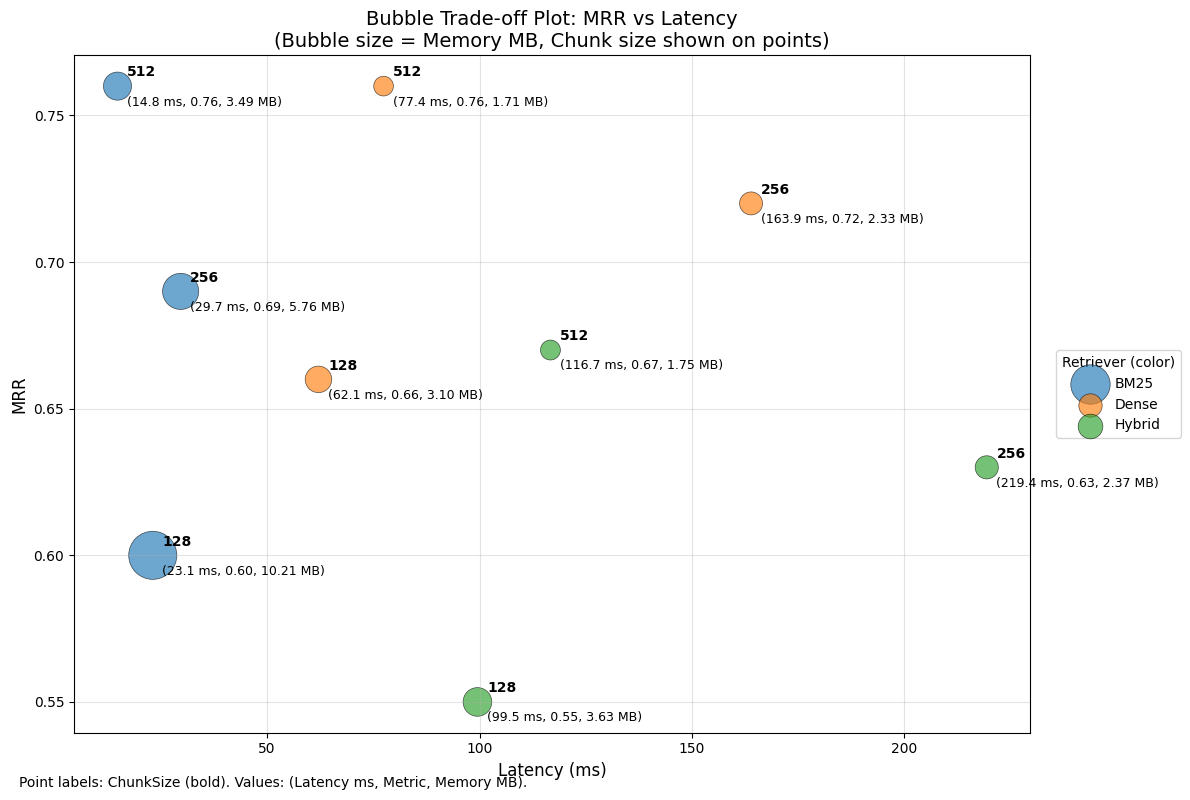

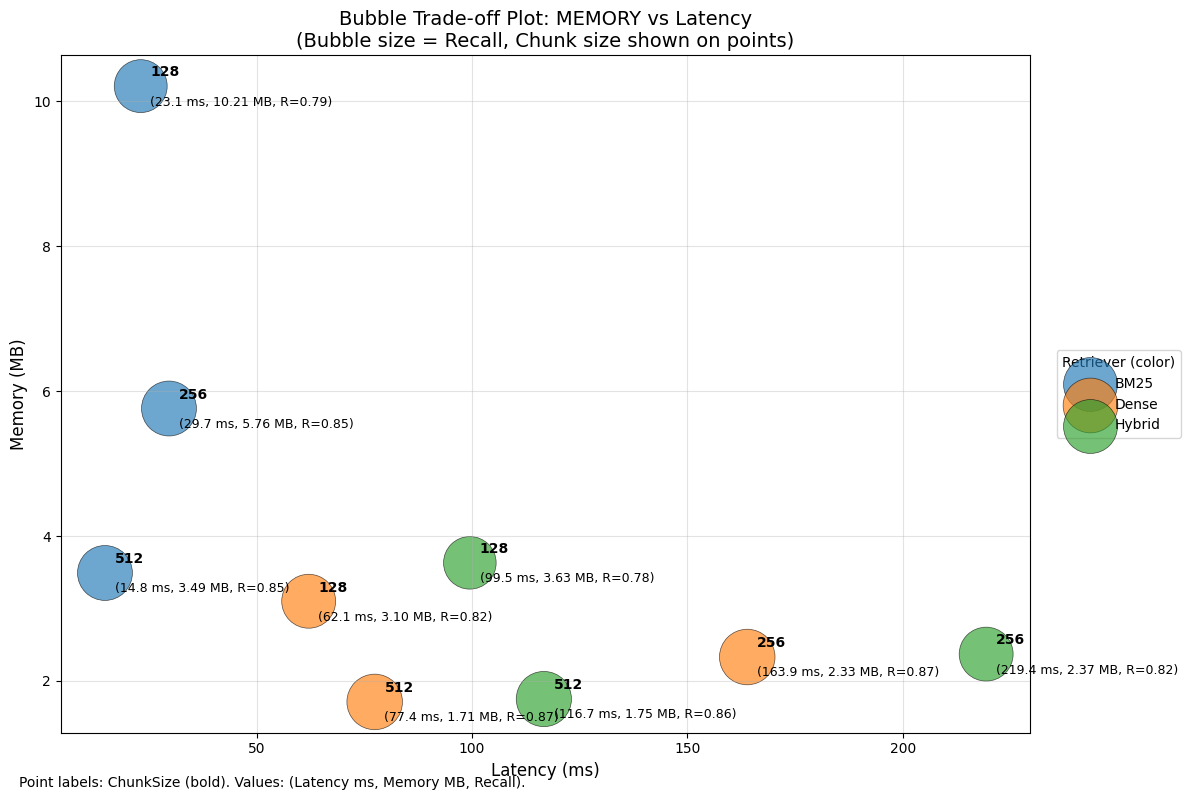

In [24]:
# ----------------------------
# 3) Generate plots
# ----------------------------

# A) Recall vs Latency (bubble size = Memory)
bubble_plot_fixed_colors(df, y_metric="recall", logx=False, figsize=(12, 8), bubble_scale=1200)

# B) MRR vs Latency (bubble size = Memory)
bubble_plot_fixed_colors(df, y_metric="mrr", logx=False, figsize=(12, 8), bubble_scale=1200)


# ----------------------------
# 4) Memory vs Latency plot (additional)
#    Here: y = memory_mb, bubble size = recall (to avoid redundancy)
# ----------------------------
def bubble_plot_memory_vs_latency(
    df,
    logx=False,
    figsize=(16, 9),
    bubble_scale=1600,
    annotate_values=True
):
    color_map = {
        "BM25":  "tab:blue",
        "Dense": "tab:orange",
        "Hybrid":"tab:green"
    }

    fig, ax = plt.subplots(figsize=figsize)

    max_recall = df["recall"].max()

    for r in ["BM25", "Dense", "Hybrid"]:
        sub = df[df["retriever"] == r].sort_values("chunk_size")

        # bubble size proportional to recall (area)
        sizes = (sub["recall"] / max_recall) * bubble_scale

        ax.scatter(
            sub["latency_ms"],
            sub["memory_mb"],
            s=sizes,
            alpha=0.65,
            color=color_map.get(r, "gray"),
            label=r,
            edgecolors="black",
            linewidths=0.5,
        )

        for _, row in sub.iterrows():
            chunk = int(row["chunk_size"])
            x = row["latency_ms"]
            mem = row["memory_mb"]
            rec = row["recall"]

            ax.annotate(
                f"{chunk}",
                (x, mem),
                textcoords="offset points",
                xytext=(7, 7),
                ha="left",
                fontsize=10,
                fontweight="bold"
            )

            if annotate_values:
                ax.annotate(
                    f"({x:.1f} ms, {mem:.2f} MB, R={rec:.2f})",
                    (x, mem),
                    textcoords="offset points",
                    xytext=(7, -14),
                    ha="left",
                    fontsize=9
                )

    ax.set_xlabel("Latency (ms)", fontsize=12)
    ax.set_ylabel("Memory (MB)", fontsize=12)
    ax.set_title(
        "Bubble Trade-off Plot: MEMORY vs Latency\n"
        "(Bubble size = Recall, Chunk size shown on points)",
        fontsize=14
    )
    ax.grid(True, alpha=0.35)

    if logx:
        ax.set_xscale("log")

    ax.legend(
        title="Retriever (color)",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )

    if annotate_values:
        fig.text(
            0.02, 0.01,
            "Point labels: ChunkSize (bold). Values: (Latency ms, Memory MB, Recall).",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()


# C) Memory vs Latency (bubble size = Recall)
bubble_plot_memory_vs_latency(df, logx=False, figsize=(12, 8), bubble_scale=1600)

# Optional log-x:
# bubble_plot_memory_vs_latency(df, logx=True, figsize=(16, 9), bubble_scale=1600)


In [25]:
import matplotlib.pyplot as plt
import numpy as np

retrievers = ["Dense", "Hybrid"]

results = {
    "Low": {
        "Recall": [0.63, 0.52],
        "MRR": [0.47, 0.36],
        "Latency": [64.64, 143.90],
        "Memory": [10.16, 10.20]
    },
    "Medium": {
        "Recall": [0.84, 0.80],
        "MRR": [0.76, 0.66],
        "Latency": [79.42, 116.65],
        "Memory": [1.71, 1.75]
    },
    "High": {
        "Recall": [0.66, 0.55],
        "MRR": [0.49, 0.37],
        "Latency": [68.99, 153.71],
        "Memory": [10.27, 10.23]
    }
}


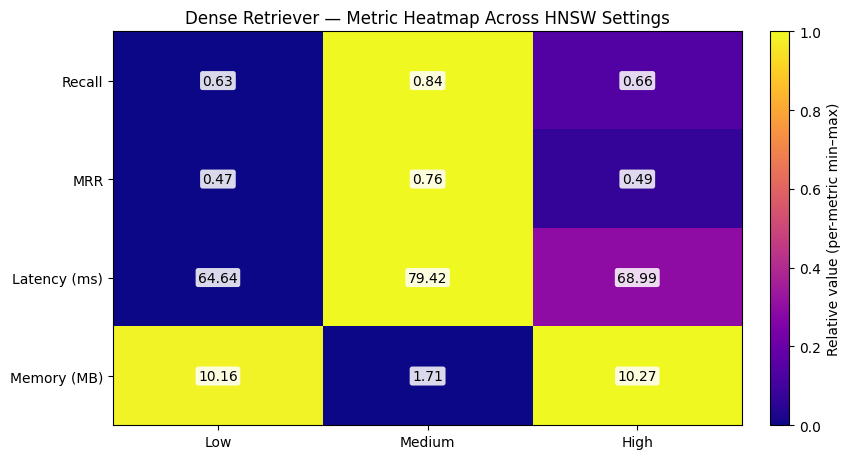

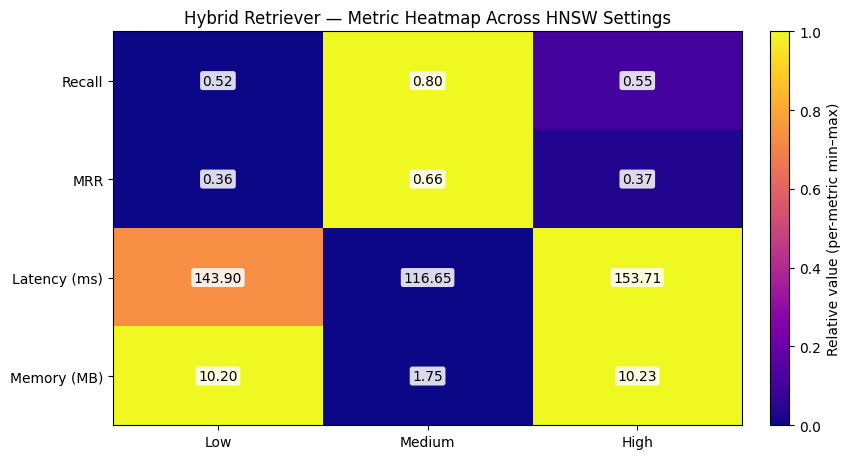

In [34]:
import numpy as np
import matplotlib.pyplot as plt

settings = ["Low", "Medium", "High"]
metrics = ["Recall", "MRR", "Latency (ms)", "Memory (MB)"]

dense = np.array([
    [0.63, 0.47,  64.64, 10.16],
    [0.84, 0.76,  79.42,  1.71],
    [0.66, 0.49,  68.99, 10.27],
], dtype=float)

hybrid = np.array([
    [0.52, 0.36, 143.90, 10.20],
    [0.80, 0.66, 116.65,  1.75],
    [0.55, 0.37, 153.71, 10.23],
], dtype=float)

def minmax_per_metric(mat):
    mins = mat.min(axis=0)
    maxs = mat.max(axis=0)
    denom = np.where(maxs - mins == 0, 1, maxs - mins)
    return (mat - mins) / denom

def plot_heatmap_readable(title, raw_mat, figsize=(8.6, 4.7), cmap="plasma"):
    scaled = minmax_per_metric(raw_mat)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(scaled.T, aspect="auto", cmap=cmap)

    ax.set_xticks(np.arange(len(settings)))
    ax.set_xticklabels(settings)
    ax.set_yticks(np.arange(len(metrics)))
    ax.set_yticklabels(metrics)

    # Put text in a white box so the heatmap never hides it
    for i in range(len(metrics)):
        for j in range(len(settings)):
            ax.text(
                j, i, f"{raw_mat[j, i]:.2f}",
                ha="center", va="center",
                color="black",
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85)
            )

    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Relative value (per-metric min–max)")

    plt.tight_layout()
    plt.show()

plot_heatmap_readable("Dense Retriever — Metric Heatmap Across HNSW Settings", dense, cmap="plasma")
plot_heatmap_readable("Hybrid Retriever — Metric Heatmap Across HNSW Settings", hybrid, cmap="plasma")


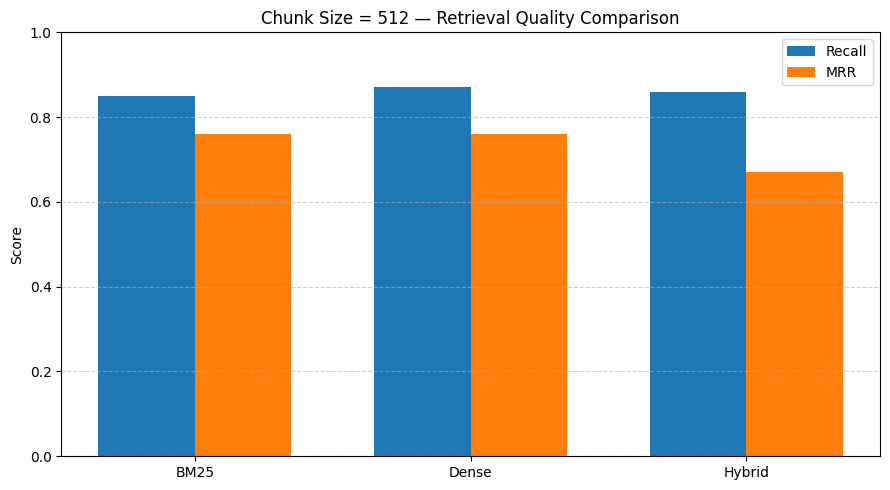

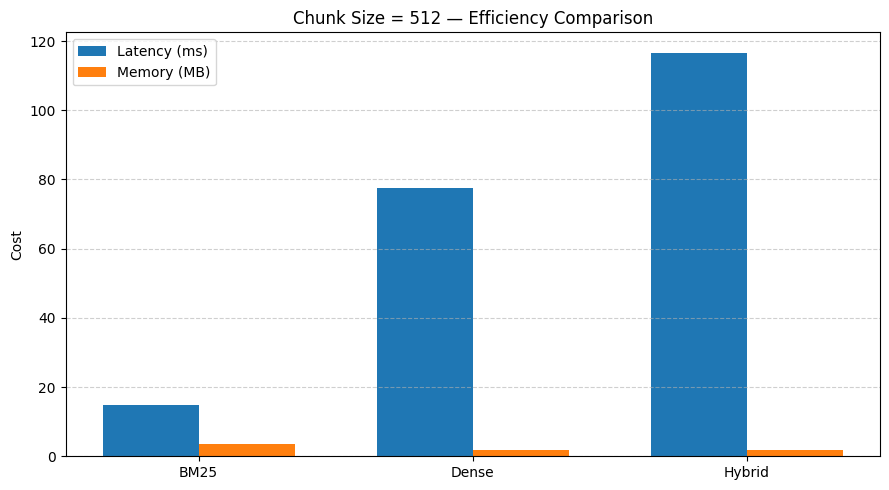

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Data for Chunk Size = 512
retrievers = ["BM25", "Dense", "Hybrid"]

recall = [0.85, 0.87, 0.86]
mrr = [0.76, 0.76, 0.67]
latency = [14.81, 77.42, 116.69]
memory = [3.49, 1.71, 1.75]

x = np.arange(len(retrievers))
width = 0.35

# Plot 1: Quality metrics (Recall & MRR)
plt.figure(figsize=(9, 5))
plt.bar(x - width/2, recall, width, label="Recall")
plt.bar(x + width/2, mrr, width, label="MRR")
plt.xticks(x, retrievers)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Chunk Size = 512 — Retrieval Quality Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Plot 2: Efficiency metrics (Latency & Memory)
plt.figure(figsize=(9, 5))
plt.bar(x - width/2, latency, width, label="Latency (ms)")
plt.bar(x + width/2, memory, width, label="Memory (MB)")
plt.xticks(x, retrievers)
plt.ylabel("Cost")
plt.title("Chunk Size = 512 — Efficiency Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


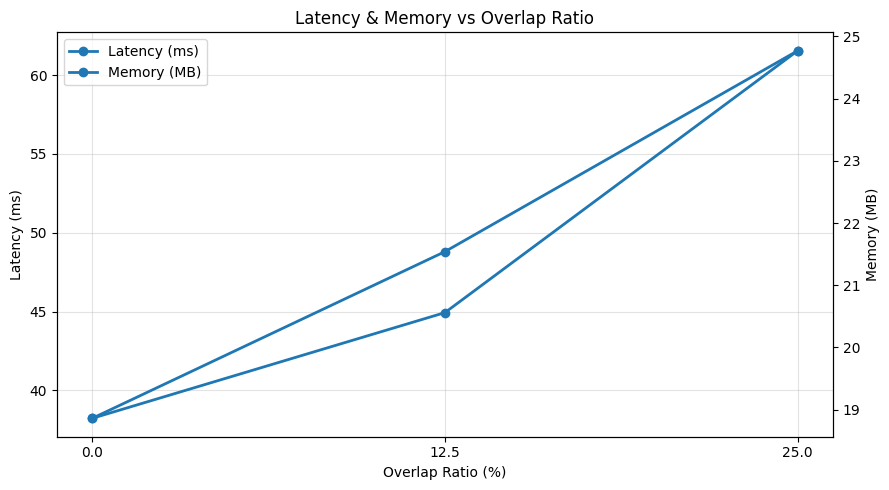

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "overlap_ratio_pct": [0.0, 12.5, 25.0],
    "latency_ms": [38.22, 44.93, 61.55],
    "memory_mb": [18.86, 21.54, 24.77],
})

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(df["overlap_ratio_pct"], df["latency_ms"], marker="o", linewidth=2, label="Latency (ms)")
ax1.set_xlabel("Overlap Ratio (%)")
ax1.set_ylabel("Latency (ms)")
ax1.set_xticks(df["overlap_ratio_pct"])
ax1.grid(True, alpha=0.35)

ax2 = ax1.twinx()
ax2.plot(df["overlap_ratio_pct"], df["memory_mb"], marker="o", linewidth=2, label="Memory (MB)")
ax2.set_ylabel("Memory (MB)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Latency & Memory vs Overlap Ratio")
fig.tight_layout()
plt.show()


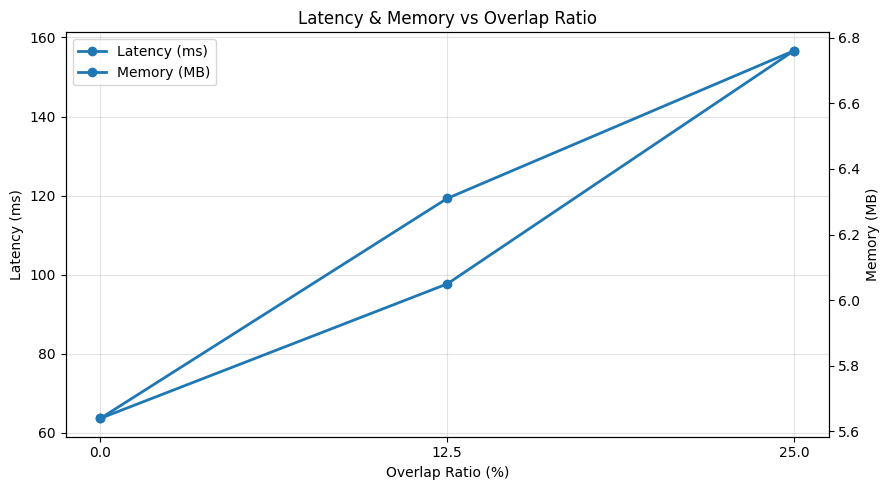

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Data from the new table
df = pd.DataFrame({
    "overlap_ratio_pct": [0.0, 12.5, 25.0],
    "latency_ms": [63.63, 97.64, 156.65],
    "memory_mb": [5.64, 6.31, 6.76],
})

fig, ax1 = plt.subplots(figsize=(9, 5))

# Latency plot
ax1.plot(df["overlap_ratio_pct"], df["latency_ms"], marker="o", linewidth=2, label="Latency (ms)")
ax1.set_xlabel("Overlap Ratio (%)")
ax1.set_ylabel("Latency (ms)")
ax1.set_xticks(df["overlap_ratio_pct"])
ax1.grid(True, alpha=0.35)

# Memory plot (secondary axis)
ax2 = ax1.twinx()
ax2.plot(df["overlap_ratio_pct"], df["memory_mb"], marker="o", linewidth=2, label="Memory (MB)")
ax2.set_ylabel("Memory (MB)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Latency & Memory vs Overlap Ratio")
fig.tight_layout()
plt.show()


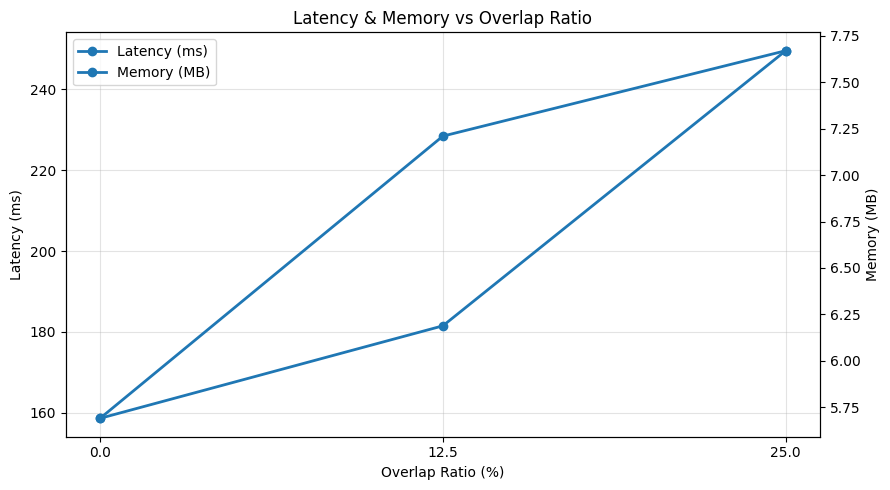

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Data from the table
df = pd.DataFrame({
    "overlap_ratio_pct": [0.0, 12.5, 25.0],
    "latency_ms": [158.61, 181.50, 249.57],
    "memory_mb": [5.69, 7.21, 7.67],
})

fig, ax1 = plt.subplots(figsize=(9, 5))

# Latency line
ax1.plot(df["overlap_ratio_pct"], df["latency_ms"], marker="o", linewidth=2, label="Latency (ms)")
ax1.set_xlabel("Overlap Ratio (%)")
ax1.set_ylabel("Latency (ms)")
ax1.set_xticks(df["overlap_ratio_pct"])
ax1.grid(True, alpha=0.35)

# Memory line on secondary axis
ax2 = ax1.twinx()
ax2.plot(df["overlap_ratio_pct"], df["memory_mb"], marker="o", linewidth=2, label="Memory (MB)")
ax2.set_ylabel("Memory (MB)")

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Latency & Memory vs Overlap Ratio")
fig.tight_layout()
plt.show()


,Table,Retriever,Model,EM,F1
0,Chunk Size = 128,BM25,LLAMA,0.16,0.25
1,Chunk Size = 128,BM25,Qwen 3b,0.40,0.43
2,Chunk Size = 128,BM25,Qwen 7b,0.36,0.43
3,Chunk Size = 128,Dense,LLAMA,0.28,0.37
4,Chunk Size = 128,Dense,Qwen 3b,0.38,0.45
5,Chunk Size = 128,Dense,Qwen 7b,0.42,0.49
6,Chunk Size = 128,Hybrid,LLAMA,0.20,0.31
7,Chunk Size = 128,Hybrid,Qwen 3b,0.40,0.46
8,Chunk Size = 128,Hybrid,Qwen 7b,0.41,0.45
9,Chunk Size = 256,BM25,LLAMA,0.16,0.30


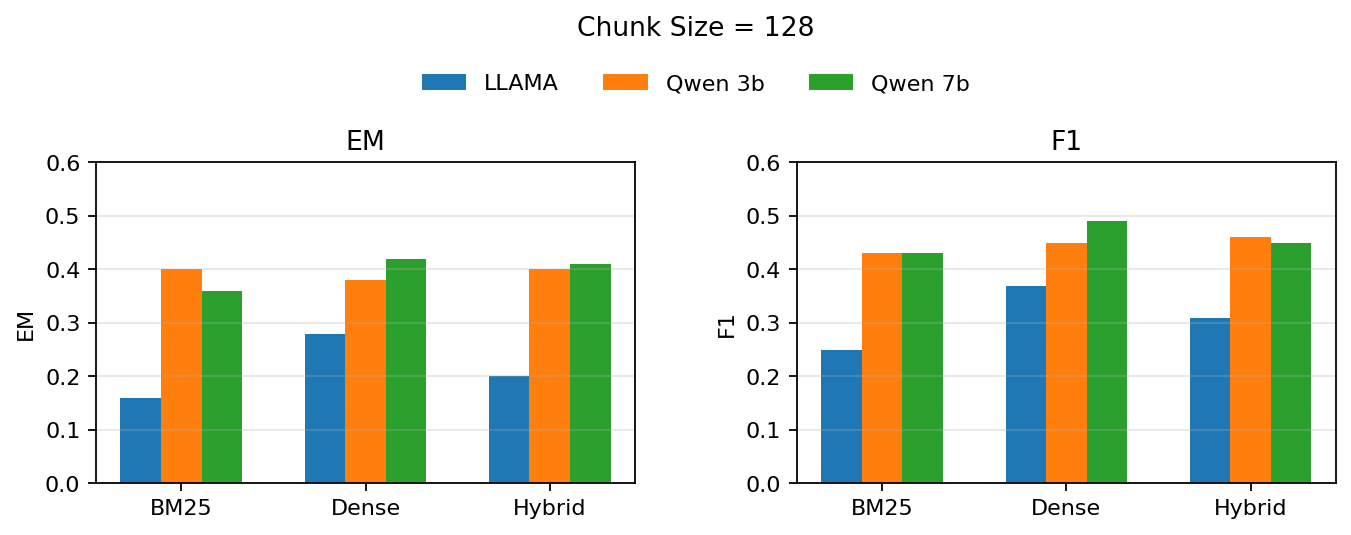

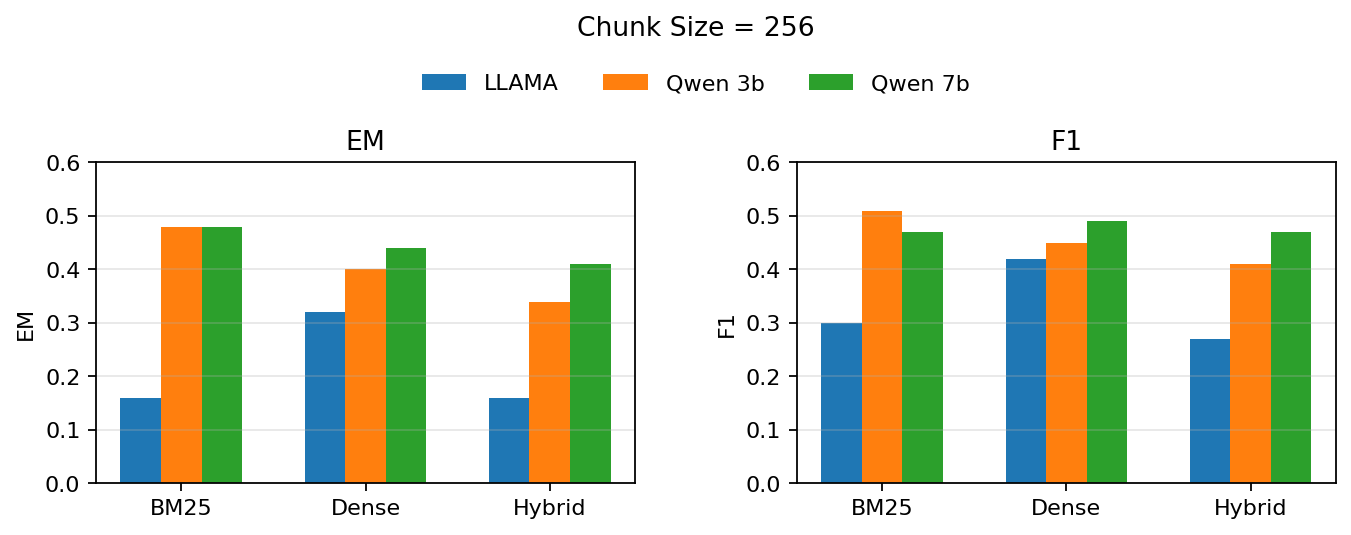

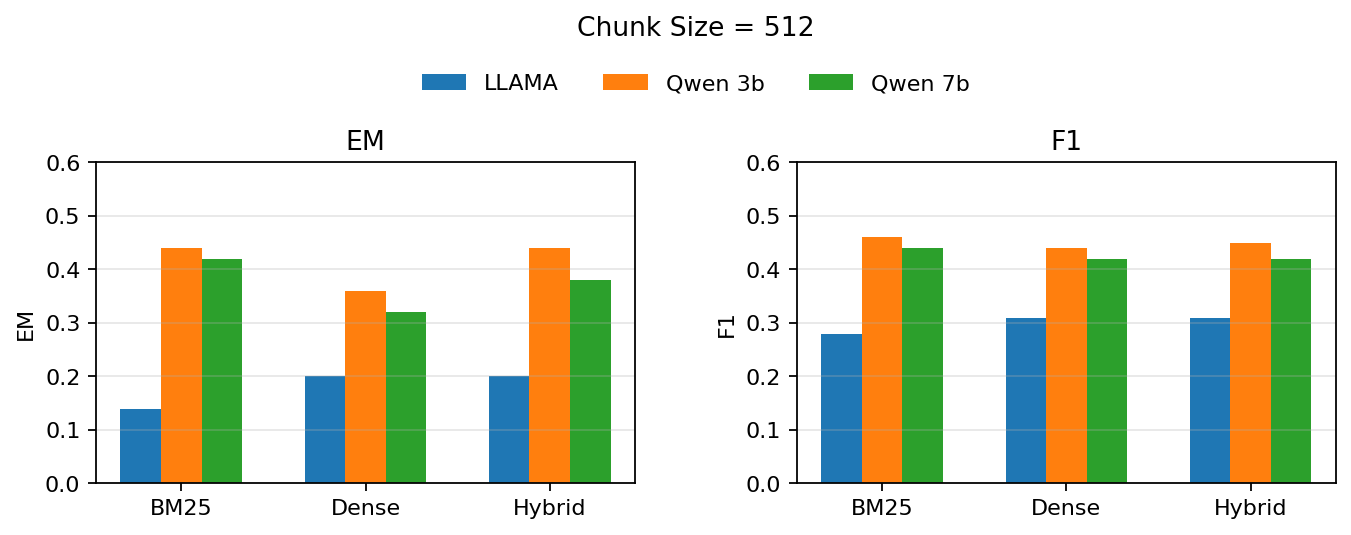

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Enter the table values
# -----------------------------
tables = {
    "Chunk Size = 128": {
        "BM25":  {"LLAMA": (0.16, 0.25), "Qwen 3b": (0.40, 0.43), "Qwen 7b": (0.36, 0.43)},
        "Dense": {"LLAMA": (0.28, 0.37), "Qwen 3b": (0.38, 0.45), "Qwen 7b": (0.42, 0.49)},
        "Hybrid":{"LLAMA": (0.20, 0.31), "Qwen 3b": (0.40, 0.46), "Qwen 7b": (0.41, 0.45)},
    },
    "Chunk Size = 256": {
        "BM25":  {"LLAMA": (0.16, 0.30), "Qwen 3b": (0.48, 0.51), "Qwen 7b": (0.48, 0.47)},
        "Dense": {"LLAMA": (0.32, 0.42), "Qwen 3b": (0.40, 0.45), "Qwen 7b": (0.44, 0.49)},
        "Hybrid":{"LLAMA": (0.16, 0.27), "Qwen 3b": (0.34, 0.41), "Qwen 7b": (0.41, 0.47)},
    },
    "Chunk Size = 512": {
        "BM25":  {"LLAMA": (0.14, 0.28), "Qwen 3b": (0.44, 0.46), "Qwen 7b": (0.42, 0.44)},
        "Dense": {"LLAMA": (0.20, 0.31), "Qwen 3b": (0.36, 0.44), "Qwen 7b": (0.32, 0.42)},
        "Hybrid":{"LLAMA": (0.20, 0.31), "Qwen 3b": (0.44, 0.45), "Qwen 7b": (0.38, 0.42)},
    }
}

# Build a tidy dataframe: Table, Retriever, Model, EM, F1
rows = []
for tname, retrievers in tables.items():
    for retr, models in retrievers.items():
        for model, (em, f1) in models.items():
            rows.append({"Table": tname, "Retriever": retr, "Model": model, "EM": em, "F1": f1})

df = pd.DataFrame(rows)
display(df.head(10))

# -----------------------------
# 2) Plotting function
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_em_f1_side_by_side(df, table_name):
    d = df[df["Table"] == table_name].copy()
    retrievers = ["BM25", "Dense", "Hybrid"]
    models = ["LLAMA", "Qwen 3b", "Qwen 7b"]

    x = np.arange(len(retrievers))
    width = 0.22

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), dpi=160)

    # Extra top space for title + legend
    fig.subplots_adjust(top=0.70, wspace=0.30)

    for ax, metric in zip(axes, ["EM", "F1"]):
        pivot = (d.pivot(index="Retriever", columns="Model", values=metric)
                   .reindex(index=retrievers, columns=models))

        for i, m in enumerate(models):
            ax.bar(x + (i - 1) * width, pivot[m].values, width, label=m)

        ax.set_xticks(x)
        ax.set_xticklabels(retrievers)
        ax.set_ylim(0, 0.6)
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.grid(axis="y", alpha=0.3)

    # Legend slightly LOWER than before
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 0.90)
    )

    # Title slightly HIGHER than before
    fig.suptitle(table_name, fontsize=12, y=0.97)

    plt.show()


for t in ["Chunk Size = 128", "Chunk Size = 256", "Chunk Size = 512"]:
    plot_em_f1_side_by_side(df, t)
